---

# Data Transformation and Feature Scaling

This notebook demonstrates various techniques for preparing and transforming features in datasets. These steps are crucial for improving data consistency, handling diverse feature scales, and optimizing model performance. Below are detailed notes on the processes included in this notebook.

---



In [2]:
import pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

np.set_printoptions(precision=3)

---

## Initial Data Loading and Exploration

1. **Objective**:
   - Load the processed diabetes dataset for feature transformation.
   - Inspect the dataset structure, size, and summary statistics.

2. **Steps**:
   - Use exploratory data analysis (EDA) to understand feature distributions.
   - Separate the dataset into features (`features_df`) and target (`target_df`) for downstream transformations.

---


In [3]:
df = pandas.read_csv("../data/interim/diabetes_processed.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,219.028414,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,70.341550,26.6,0.351,31.0,0
2,8.0,183.0,64.0,32.0,270.573172,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.000000,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.000000,43.1,2.288,33.0,1


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.00
Glucose,768.0,121.656250,30.438286,44.000000,99.750000,117.000000,140.250000,199.00
BloodPressure,768.0,72.405184,12.096346,24.000000,64.000000,72.202592,80.000000,122.00
SkinThickness,768.0,29.994792,8.886506,7.000000,25.000000,32.000000,32.000000,99.00
Insulin,768.0,152.815064,97.206638,-16.568152,89.976015,131.100779,189.857469,846.00
BMI,768.0,32.450911,6.875366,18.200000,27.500000,32.000000,36.600000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.42
Age,768.0,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.00
Outcome,768.0,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.00


---

## Normalization Techniques

1. **Objective**:
   - Normalize features to fit within specific ranges for better interpretability and consistent scaling.

2. **Techniques**:
   - **Min-Max Scaling**:
     - Scales features to fit within a range (default is `[0, 1]`), reducing the influence of outliers.
   - **L1/L2/Max Normalization**:
     - Normalize features based on the length of vector norms, adjusting values row-wise to sum to 1 or to align with other vector properties.

3. **Outcomes**:
   - Box plots and summary statistics are generated to validate the effects of normalization.

---


In [6]:
# podatne na outliery
features_df = df.drop("Outcome", axis=1)
target_df = df["Outcome"]

In [7]:
#przekształca dane
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
rescaled_features = scaler.fit_transform(features_df)

In [8]:
# Display first 5 rows of normalized features to verify transformation
# without overwhelming output with full dataset
rescaled_features[:5]

array([[0.353, 0.671, 0.49 , 0.304, 0.273, 0.315, 0.234, 0.483],
       [0.059, 0.265, 0.429, 0.239, 0.101, 0.172, 0.117, 0.167],
       [0.471, 0.897, 0.408, 0.272, 0.333, 0.104, 0.254, 0.183],
       [0.059, 0.29 , 0.429, 0.174, 0.128, 0.202, 0.038, 0.   ],
       [0.   , 0.6  , 0.163, 0.304, 0.214, 0.509, 0.944, 0.2  ]])

In [9]:
rescaled_features_df = pd.DataFrame(rescaled_features, columns=features_df.columns)

In [10]:
rescaled_features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,0.226180,0.198210,0.0,0.058824,0.176471,0.352941,1.0
Glucose,768.0,0.501008,0.196376,0.0,0.359677,0.470968,0.620968,1.0
BloodPressure,768.0,0.493930,0.123432,0.0,0.408163,0.491863,0.571429,1.0
SkinThickness,768.0,0.249943,0.096592,0.0,0.195652,0.271739,0.271739,1.0
Insulin,768.0,0.196371,0.112694,0.0,0.123520,0.171197,0.239315,1.0
BMI,768.0,0.291430,0.140601,0.0,0.190184,0.282209,0.376278,1.0
DiabetesPedigreeFunction,768.0,0.168179,0.141473,0.0,0.070773,0.125747,0.234095,1.0
Age,768.0,0.204015,0.196004,0.0,0.050000,0.133333,0.333333,1.0


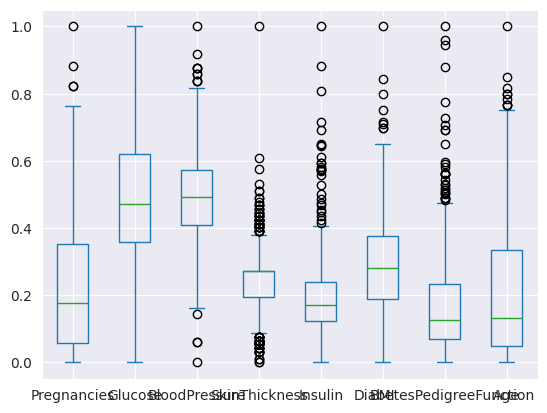

In [11]:

fig, ax = plt.subplots()
rescaled_features_df.plot(kind="box", ax=ax)
plt.show()

---

## Standardization Techniques

1. **Objective**:
   - Standardize features by centering to the mean and scaling to unit variance.

2. **Technique**:
   - **StandardScaler**:
     - Useful for data where the mean and variance differ significantly between features.

3. **Steps**:
   - Apply standardization and verify transformed features using box plots and statistics.

---


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardized_features = scaler.fit_transform(features_df)

In [13]:
standardized_features[:5]

array([[ 0.64 ,  0.866, -0.034,  0.564,  0.682,  0.167,  0.468,  1.426],
       [-0.845, -1.205, -0.53 , -0.112, -0.849, -0.852, -0.365, -0.191],
       [ 1.234,  2.017, -0.695,  0.226,  1.212, -1.332,  0.604, -0.106],
       [-0.845, -1.074, -0.53 , -0.788, -0.605, -0.633, -0.921, -1.042],
       [-1.142,  0.504, -2.681,  0.564,  0.156,  1.55 ,  5.485, -0.02 ]])

In [14]:
standardized_features_df = pd.DataFrame(standardized_features, columns=features_df.columns)

In [15]:
standardized_features_df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,-6.476301e-17,1.000652,-1.141852,-0.844885,-0.250952,0.639947,3.906578
Glucose,768.0,4.625929e-18,1.000652,-2.552931,-0.720163,-0.153073,0.611265,2.542658
BloodPressure,768.0,6.915764e-16,1.000652,-4.004245,-0.695306,-0.016759,0.628269,4.102655
SkinThickness,768.0,-1.318390e-16,1.000652,-2.589294,-0.562431,0.225793,0.225793,7.770228
Insulin,768.0,2.775558e-17,1.000652,-1.743642,-0.646869,-0.223528,0.381317,7.135692
BMI,768.0,4.672189e-16,1.000652,-2.074100,-0.720563,-0.065626,0.603865,5.042883
DiabetesPedigreeFunction,768.0,2.451743e-16,1.000652,-1.189553,-0.688969,-0.300128,0.466227,5.883565
Age,768.0,1.931325e-16,1.000652,-1.041549,-0.786286,-0.360847,0.660206,4.063716


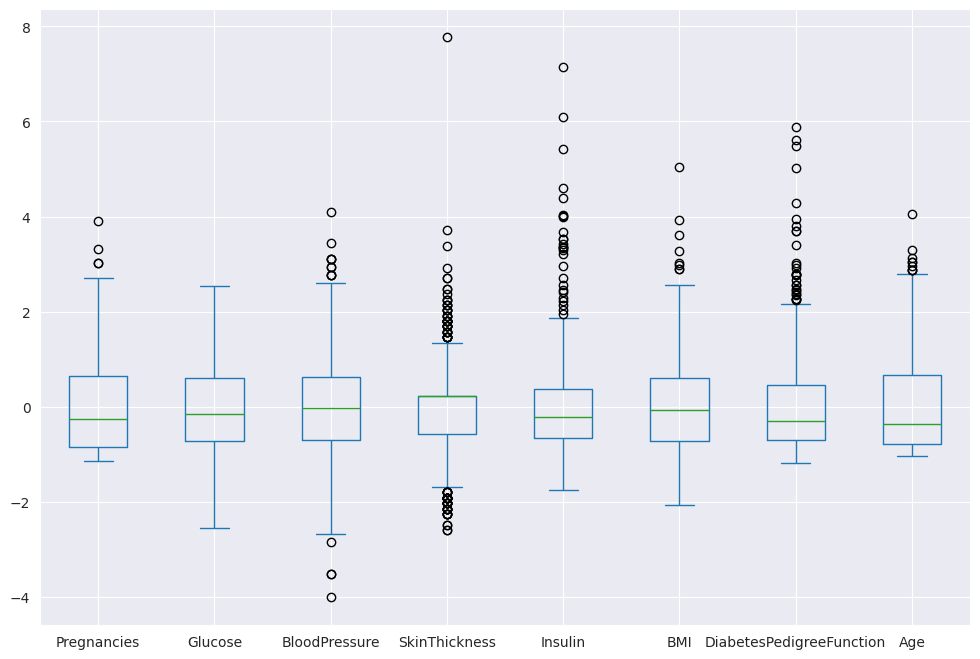

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))
standardized_features_df.plot(kind="box", ax=ax)

plt.show()


In [17]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm="l1")
normalized_features = normalizer.fit_transform(features_df)
normalized_features_df = pd.DataFrame(normalized_features, columns=features_df.columns)
# Compare statistics of normalized data (L1 norm)
# Mean values are different between features because L1 normalization
# divides each feature by the sum of absolute values in a row
# This makes each row sum to 1.0
normalized_stats = normalized_features_df.describe().T
print("Key observations about L1 normalized data:")
print("\n- Mean values vary between features")
print("- Standard deviation is relatively small")
print("- Min/max ranges are proportional to feature importance in the row-wise sum")
print("\nDetailed statistics:")
normalized_stats

Key observations about L1 normalized data:

- Mean values vary between features
- Standard deviation is relatively small
- Min/max ranges are proportional to feature importance in the row-wise sum

Detailed statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,0.008783,0.007640,0.000000,0.002830,0.007020,0.012958,0.041208
Glucose,768.0,0.277573,0.041135,0.135758,0.254690,0.273784,0.297115,0.447460
BloodPressure,768.0,0.172123,0.044909,0.049648,0.143208,0.167992,0.201648,0.340415
SkinThickness,768.0,0.070320,0.023075,0.010969,0.054114,0.068402,0.083885,0.166877
Insulin,768.0,0.316056,0.102874,-0.074916,0.253162,0.313873,0.378071,0.700043
BMI,768.0,0.076590,0.020457,0.024907,0.062672,0.074705,0.088527,0.161056
DiabetesPedigreeFunction,768.0,0.001112,0.000791,0.000140,0.000547,0.000884,0.001456,0.005737
Age,768.0,0.077247,0.025737,0.022036,0.059637,0.073537,0.090728,0.252305


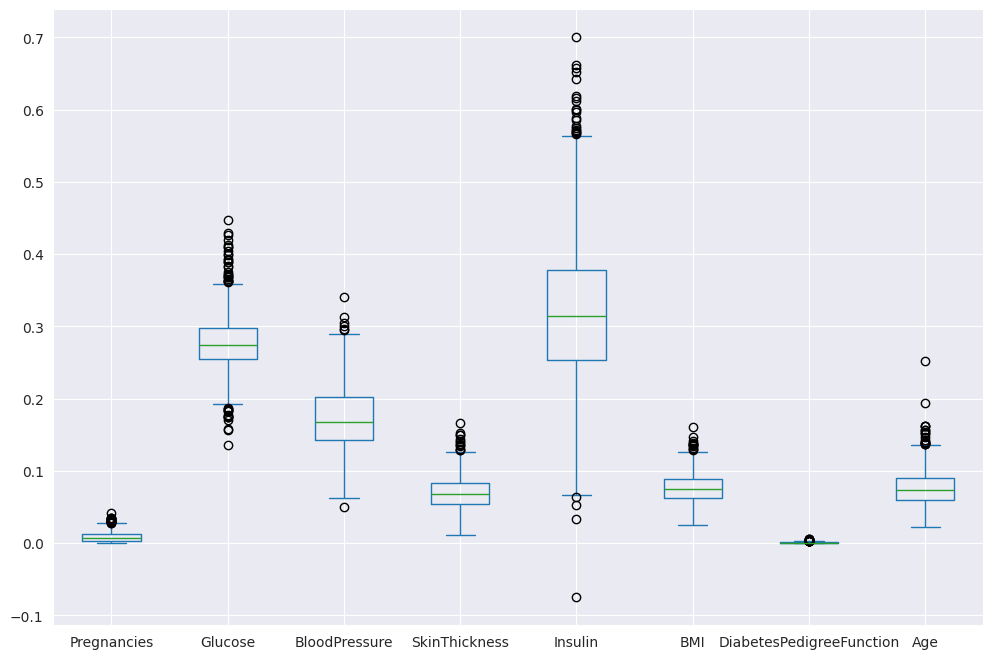

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))
normalized_features_df.plot(kind="box", ax=ax)
plt.show()

In [19]:
normalized_features_df.iloc[0].abs().sum()

np.float64(1.0)

In [20]:
normalizer = Normalizer(norm="l2")
normalized_features = normalizer.fit_transform(features_df)
normalized_features_l2_df = pd.DataFrame(normalized_features, columns=features_df.columns)

In [21]:
normalized_features_l2_df.iloc[0].pow(2).sum()

np.float64(0.9999999999999998)

In [22]:

normalizer = Normalizer(norm="max")
normalized_features = normalizer.fit_transform(features_df)
normalized_features_max_df = pd.DataFrame(normalized_features, columns=features_df.columns)
normalized_features_max_df.iloc[0]

Pregnancies                 0.027394
Glucose                     0.675711
BloodPressure               0.328724
SkinThickness               0.159797
Insulin                     1.000000
BMI                         0.153405
DiabetesPedigreeFunction    0.002863
Age                         0.228281
Name: 0, dtype: float64

In [23]:
normalized_features_max_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.027394,0.675711,0.328724,0.159797,1.000000,0.153405,0.002863,0.228281
1,0.011765,1.000000,0.776471,0.341176,0.827548,0.312941,0.004129,0.364706
2,0.029567,0.676342,0.236535,0.118267,1.000000,0.086113,0.002484,0.118267
3,0.010638,0.946809,0.702128,0.244681,1.000000,0.298936,0.001777,0.223404
4,0.000000,0.815476,0.238095,0.208333,1.000000,0.256548,0.013619,0.196429


---

## Binarization of Features

1. **Objective**:
   - Convert continuous features into binary representations based on thresholds.

2. **Technique**:
   - **Binarizer**:
     - Create binary indicators for features based on the column-specific mean values.

3. **Steps**:
   - Apply binarization across all features and validate the results.

---


In [24]:
from sklearn.preprocessing import Binarizer

binarizer = Binarizer(threshold=features_df["Pregnancies"].mean())
# pobierasz liste colum z jedną wartością
binarized_features = binarizer.fit_transform(features_df[["Pregnancies"]])

binarized_features = []

for index in range(features_df.shape[1]):
    scaler = Binarizer(threshold=float(features_df.iloc[:, index].mean()))
    new_binarized_feature = scaler.fit_transform(features_df.iloc[:, index].values.reshape(-1, 1))
    binarized_features.append(new_binarized_feature)

binarized_features = np.concatenate(binarized_features, axis=1)
binarized_features_df = pd.DataFrame(binarized_features, columns=features_df.columns)
binarized_features

array([[1., 1., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(768, 8))

---

## Model Building and Comparison

1. **Objective**:
   - Train logistic regression models to compare the impact of scaled, standardized, and binarized features.

2. **Process**:
   - Train and evaluate models for each transformation type.
   - Assess model performance using accuracy metrics.

3. **Outcomes**:
   - Identify the transformations that yield better accuracy and explainability.

---


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def build_model(X, y, test_fraction=0.2):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_fraction)

    model = LogisticRegression(solver="liblinear").fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Test score: ", accuracy_score(y_test, y_pred))


In [26]:
build_model(features_df, target_df)

Test score:  0.7597402597402597


In [27]:
build_model(rescaled_features_df, target_df)

Test score:  0.7532467532467533


In [28]:
build_model(standardized_features_df, target_df)

Test score:  0.8051948051948052


In [29]:
build_model(normalized_features_df, target_df)

Test score:  0.6168831168831169


In [30]:
build_model(binarized_features_df, target_df)

Test score:  0.6883116883116883


In [31]:
build_model(normalized_features_l2_df, target_df)

Test score:  0.6883116883116883


In [32]:
build_model(normalized_features_max_df, target_df)

Test score:  0.7012987012987013


---

## Discretization (Binning)

1. **Objective**:
   - Group continuous feature values into discrete intervals (bins).

2. **Techniques**:
   - **Pandas `cut`**:
     - Create equal-width bins for numerical data.
   - **KBinsDiscretizer**:
     - Generate bins using quantile-based or uniform strategies.

3. **Steps**:
   - Apply binning techniques to features for reducing data variability and improving model interpretability.
   - Visualize and validate the binning results.

---


In [33]:
df = pd.read_csv('../data/raw/GoSales_Tx_LogisticRegression.csv')
df.head()


,IS_TENT,GENDER,AGE,MARITAL_STATUS,PROFESSION
0,False,M,27,Single,Professional
1,False,F,39,Married,Other
2,False,F,39,Married,Other
3,False,F,56,Unspecified,Hospitality
4,False,M,45,Married,Retired


In [34]:
df.shape

(60252, 5)

In [35]:
df["AGE"].describe()

count    60252.000000
mean        34.187479
std         10.105477
min         17.000000
25%         26.000000
50%         33.000000
75%         41.000000
max         69.000000
Name: AGE, dtype: float64

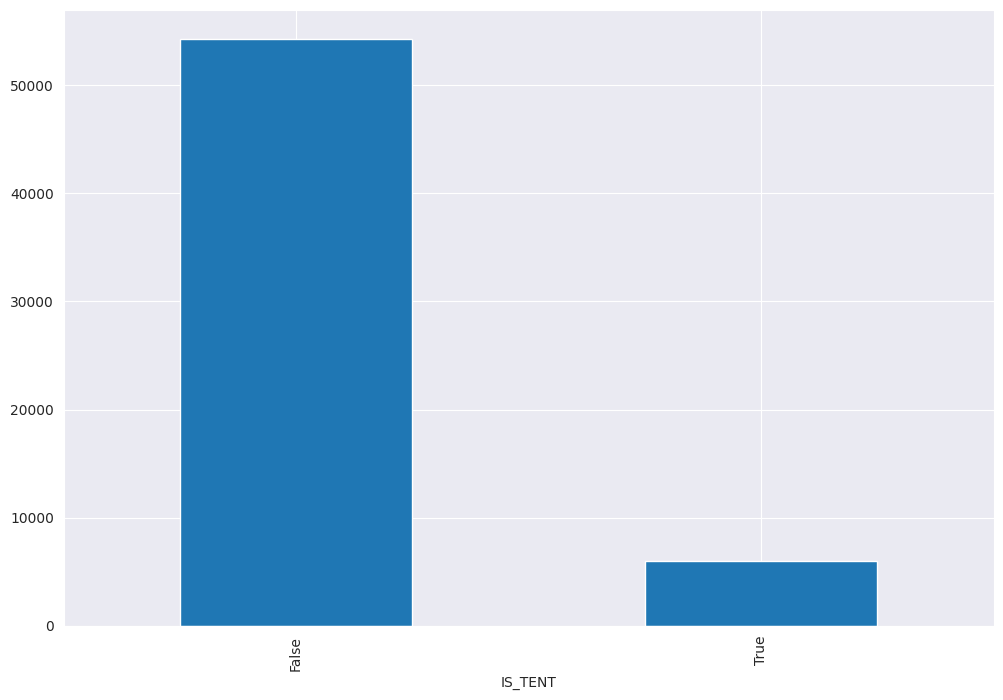

In [36]:
fig, ax = plt.subplots(figsize=(12, 8))

df["IS_TENT"].value_counts().plot(kind="bar", ax=ax)

plt.show()

In [37]:
df["MARITAL_STATUS"].value_counts()

MARITAL_STATUS
Married        30779
Single         24549
Unspecified     4924
Name: count, dtype: int64

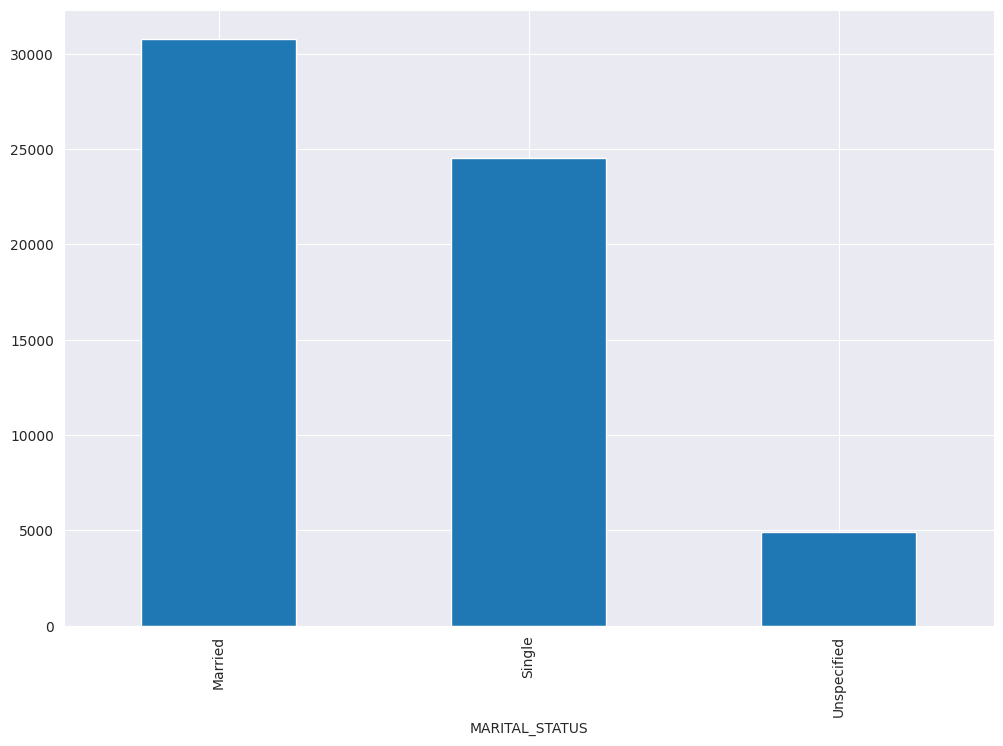

In [38]:
fig, ax = plt.subplots(figsize=(12, 8))

df["MARITAL_STATUS"].value_counts().plot(kind="bar", ax=ax)

plt.show()

In [39]:
df["PROFESSION"].value_counts()

PROFESSION
Other           24503
Professional     8938
Sales            6708
Executive        5871
Trades           4008
Hospitality      3311
Student          2945
Retail           2785
Retired          1183
Name: count, dtype: int64

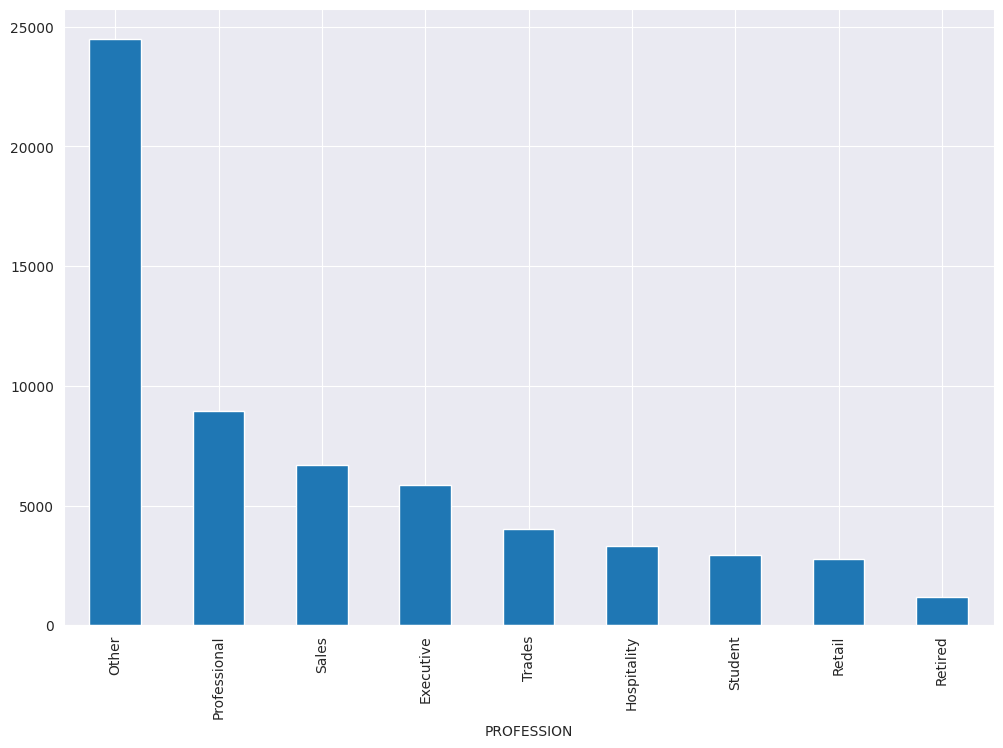

In [40]:
fig, ax = plt.subplots(figsize=(12, 8))

df["PROFESSION"].value_counts().plot(kind="bar", ax=ax)

plt.show()

---

## Encoding Categorical Data

1. **Objective**:
   - Process categorical features for use in numerical models.

2. **Techniques**:
   - **Label Encoding**:
     - Convert categorical labels into integer values.
   - **One-Hot Encoding**:
     - Represent categorical variables as binary vectors to preserve uniqueness and prevent ordinal relationships.

3. **Steps**:
   - Encode `GENDER` with `LabelEncoder` and `MARITAL_STATUS` with `OneHotEncoder`.
   - Perform additional encoding for categorical columns like `PROFESSION`.

---

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder().fit(["M", "F"])
df["GENDER"] = label_encoder.transform(df["GENDER"])
label_encoder.classes_


array(['F', 'M'], dtype='<U1')

In [42]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder().fit(df[["MARITAL_STATUS"]])
one_hot_encoder.categories_

[array(['Married', 'Single', 'Unspecified'], dtype=object)]

In [43]:
_labels = one_hot_encoder.transform(df[["MARITAL_STATUS"]]).toarray()

In [44]:
_labels

array([[0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]], shape=(60252, 3))

In [45]:
labels_df = pd.DataFrame()

labels_df["MARITAL_STATUS_Married"] = _labels[:, 0]
labels_df["MARITAL_STATUS_Single"] = _labels[:, 1]
labels_df["MARITAL_STATUS_Unspecified"] = _labels[:, 2]
labels_df.head(10)

,MARITAL_STATUS_Married,MARITAL_STATUS_Single,MARITAL_STATUS_Unspecified
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0
5,1.0,0.0,0.0
6,1.0,0.0,0.0
7,1.0,0.0,0.0
8,1.0,0.0,0.0
9,1.0,0.0,0.0


In [46]:
encoded_df = pd.concat([df, labels_df], axis=1)
encoded_df.drop(["MARITAL_STATUS"], axis=1, inplace=True)
encoded_df.sample(10)

,IS_TENT,GENDER,AGE,PROFESSION,MARITAL_STATUS_Married,MARITAL_STATUS_Single,MARITAL_STATUS_Unspecified
22930,False,1,41,Retired,1.0,0.0,0.0
51749,True,0,32,Other,1.0,0.0,0.0
27557,False,0,28,Other,0.0,1.0,0.0
5439,False,0,28,Other,0.0,1.0,0.0
8314,False,1,30,Other,0.0,1.0,0.0
34134,False,0,33,Other,1.0,0.0,0.0
31012,False,1,40,Other,1.0,0.0,0.0
51833,False,0,32,Other,1.0,0.0,0.0
49856,False,1,21,Other,0.0,1.0,0.0
58897,False,0,40,Hospitality,0.0,0.0,1.0


In [47]:
df = pd.get_dummies(df, columns=["MARITAL_STATUS"], dtype=int)
df.head()


,IS_TENT,GENDER,AGE,PROFESSION,MARITAL_STATUS_Married,MARITAL_STATUS_Single,MARITAL_STATUS_Unspecified
0,False,1,27,Professional,0,1,0
1,False,0,39,Other,1,0,0
2,False,0,39,Other,1,0,0
3,False,0,56,Hospitality,0,0,1
4,False,1,45,Retired,1,0,0


In [48]:
df = pd.get_dummies(df, columns=["PROFESSION"], dtype=int)

In [49]:
df

,IS_TENT,GENDER,AGE,MARITAL_STATUS_Married,MARITAL_STATUS_Single,MARITAL_STATUS_Unspecified,PROFESSION_Executive,PROFESSION_Hospitality,PROFESSION_Other,PROFESSION_Professional,PROFESSION_Retail,PROFESSION_Retired,PROFESSION_Sales,PROFESSION_Student,PROFESSION_Trades
0,False,1,27,0,1,0,0,0,0,1,0,0,0,0,0
1,False,0,39,1,0,0,0,0,1,0,0,0,0,0,0
2,False,0,39,1,0,0,0,0,1,0,0,0,0,0,0
3,False,0,56,0,0,1,0,1,0,0,0,0,0,0,0
4,False,1,45,1,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60247,True,1,24,0,1,0,0,0,0,1,0,0,0,0,0
60248,False,1,24,0,1,0,0,0,0,1,0,0,0,0,0
60249,False,0,27,1,0,0,0,0,0,0,1,0,0,0,0
60250,False,0,20,0,1,0,0,0,1,0,0,0,0,0,0


# DYSKRETIZATION DYSKRETYZACJA - robienie koszyczków

---

## Applying Discretization and Regression Models

1. **Objective**:
   - Test models on discretized datasets and compare with continuous features.

2. **Process**:
   - Use `KBinsDiscretizer` for finer-grained binning.
   - Train linear regression models on binned data and evaluate R² scores and visualizations for comparison.

---


In [50]:
age = [17, 21, 23, 35, 49, 52, 60]

In [51]:
# równe koszyki ilościowo
result = pd.cut(age, bins=3)
result.categories

IntervalIndex([(16.957, 31.333], (31.333, 45.667], (45.667, 60.0]], dtype='interval[float64, right]')

In [52]:
result.codes

array([0, 0, 0, 1, 2, 2, 2], dtype=int8)

In [53]:
result = pd.cut(age, bins=3, retbins=True)
result


([(16.957, 31.333], (16.957, 31.333], (16.957, 31.333], (31.333, 45.667], (45.667, 60.0], (45.667, 60.0], (45.667, 60.0]]
 Categories (3, interval[float64, right]): [(16.957, 31.333] < (31.333, 45.667] < (45.667, 60.0]],
 array([16.957, 31.333, 45.667, 60.   ]))

In [54]:
marks = np.array([70, 20, 30, 99, 40, 16, 80])

In [55]:
categories, bins = pd.cut(marks, bins=4, retbins=True, labels=['poor', 'average', 'good', 'excellent'])
categories

['good', 'poor', 'poor', 'excellent', 'average', 'poor', 'excellent']
Categories (4, object): ['poor' < 'average' < 'good' < 'excellent']

In [56]:
from sklearn.preprocessing import KBinsDiscretizer

marks = [[70], [20], [30], [99], [40], [16], [80]]

enc = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="uniform")
enc.fit(marks)
enc.transform(marks)

array([[2.],
       [0.],
       [0.],
       [3.],
       [1.],
       [0.],
       [3.]])

In [57]:
enc.transform(marks)

array([[2.],
       [0.],
       [0.],
       [3.],
       [1.],
       [0.],
       [3.]])

In [58]:
enc.bin_edges_

array([array([16.  , 36.75, 57.5 , 78.25, 99.  ])], dtype=object)

In [59]:
x = [
    [-21, 41, -14],
    [-13, 23, -31],
    [9, 30, -5],
    [0, 24, -17],
    [10, 4, 11]
]

In [60]:
enc_quantile = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile",
                                quantile_method='averaged_inverted_cdf')
enc_quantile.fit(x)

X_trans = enc_quantile.transform(x)
X_trans

array([[0., 3., 2.],
       [1., 1., 0.],
       [3., 3., 3.],
       [2., 2., 1.],
       [3., 0., 3.]])

In [61]:
enc_quantile.bin_edges_

array([array([-21., -13.,   0.,   9.,  10.]),
       array([ 4., 23., 24., 30., 41.]),
       array([-31., -17., -14.,  -5.,  11.])], dtype=object)

In [62]:
enc_quantile.inverse_transform(X_trans)

array([[-17. ,  35.5,  -9.5],
       [ -6.5,  23.5, -24. ],
       [  9.5,  35.5,   3. ],
       [  4.5,  27. , -15.5],
       [  9.5,  13.5,   3. ]])

In [63]:
df = pd.read_csv("../data/interim/cars_processed.csv")
df

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Origin,Age
0,18.000000,8,307.0,130,3504,12.0,US,53
1,16.000000,8,304.0,150,3433,12.0,US,53
2,17.000000,8,302.0,140,3449,10.5,US,53
3,14.000000,8,454.0,220,4354,9.0,US,53
4,23.551429,8,440.0,215,4312,8.5,US,53
...,...,...,...,...,...,...,...,...
382,27.000000,4,140.0,86,2790,15.6,US,41
383,44.000000,4,97.0,52,2130,24.6,Europe,41
384,32.000000,4,135.0,84,2295,11.6,US,41
385,28.000000,4,120.0,79,2625,18.6,US,41


In [64]:
df.shape

(387, 8)

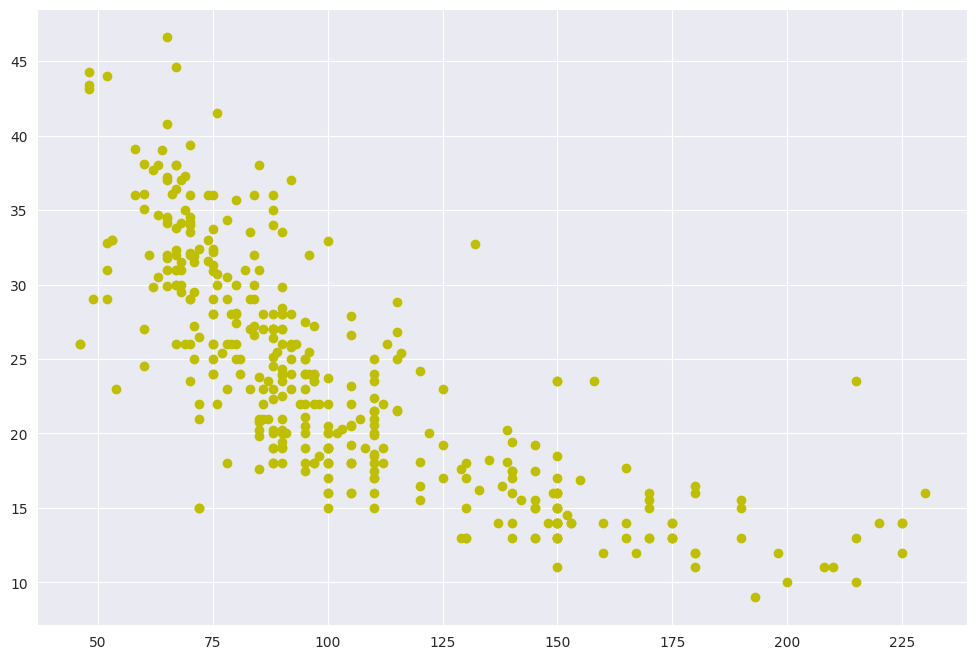

In [65]:
X = df[['Horsepower']]
y = df['MPG']

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(X, y, c="y", marker="o")
plt.show()

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
linear_reg = LinearRegression()

In [68]:
linear_reg.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
y_pred = linear_reg.predict(X_test)

In [70]:
from sklearn.metrics import r2_score

In [71]:
r2_score(y_test, y_pred)

0.6721301875260131

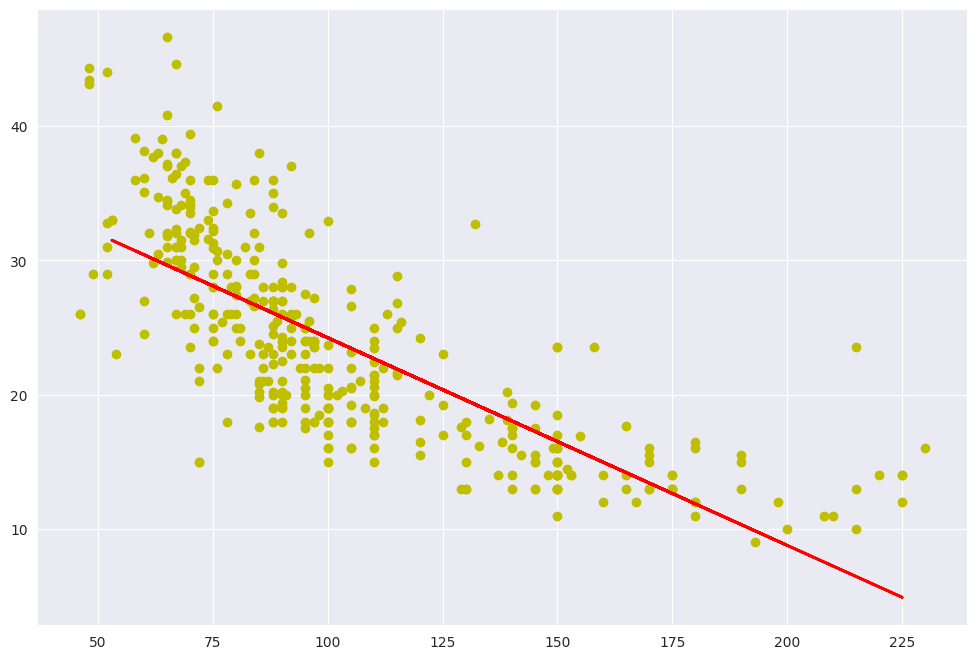

In [72]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(X, y, c="y", marker="o", label="Original data")

ax.plot(X_test, y_pred, c="r",linewidth=2, linestyle='-', label="Linear regression")


plt.show()

In [73]:
enc = KBinsDiscretizer(n_bins=20, encode="ordinal", strategy="quantile",
                                quantile_method='averaged_inverted_cdf')

In [81]:
X_binned = enc.fit_transform(X_train)
X_binned[:10]

array([[18.],
       [ 0.],
       [14.],
       [11.],
       [ 7.],
       [14.],
       [ 5.],
       [ 7.],
       [16.],
       [ 2.]])

In [82]:
X_test_binned = enc.transform(X_test)
reg = LinearRegression().fit(X_binned, y_train)
y_pred = reg.predict(X_test_binned)
r2_score(y_test, y_pred)

0.7341055797847386

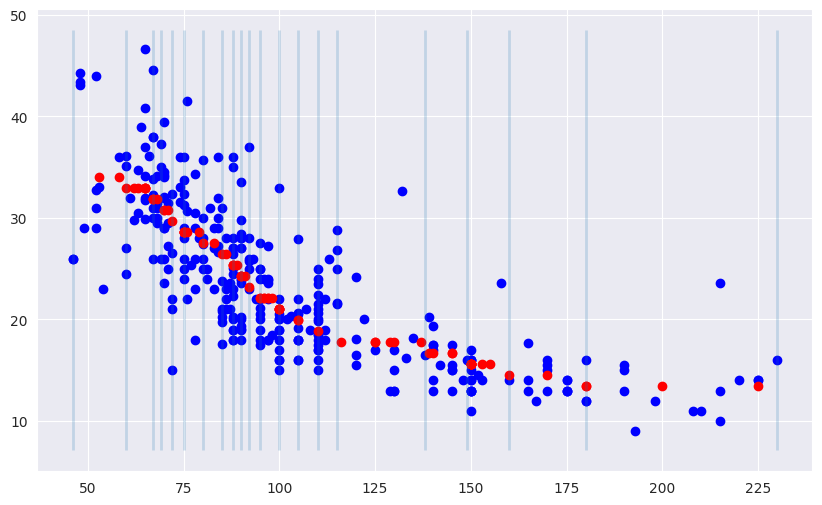

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_train, y_train, c="b", marker="o", label="Original data")
ax.scatter(X_test, y_pred, c="r", marker="o", label="Original data")
ax.vlines(enc.bin_edges_[0], *plt.gca().get_ylim(), linewidth=2, alpha=0.2, label="Bin edges")
#
# ax.plot(X_test, y_pred, c="r",linewidth=2, linestyle='-', label="Linear regression")


plt.show()

---

## Conclusion

This notebook demonstrates how to preprocess, transform, and scale datasets for effective model training. Key processes include:
- Feature scaling (normalization, standardization).
- Feature binarization for threshold-based modeling.
- Encoding categorical data for numerical model compatibility.
- Discretization for reducing feature complexity.
- Comparing model performance across transformed datasets.

---
